Loop ≥6? True
Terminals: ['Zoo', 'Gallery']
Hubs (deg≥3): ['Harbour', 'University', 'Hills', 'River']
Bridges: [('Hills', 'Zoo'), ('River', 'Gallery')]
Lines: ['Blue', 'Green', 'Orange', 'Purple', 'Red']


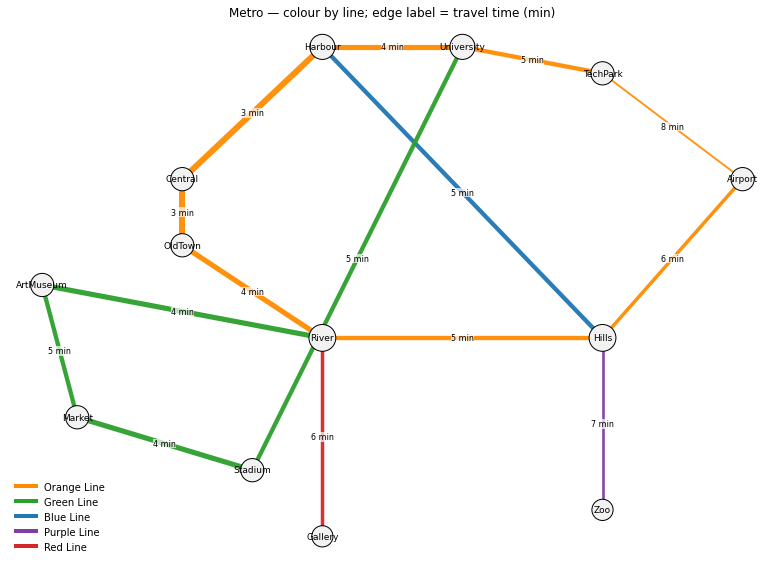

In [1]:
# install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt

# ---------- Build graph: edge attribute 'weight' = travel time (minutes) ----------
G = nx.Graph()
edges = [
    # ORANGE RING (8-stop loop)
    ("Central","Harbour","Orange",3),
    ("Harbour","University","Orange",4),
    ("University","TechPark","Orange",5),
    ("TechPark","Airport","Orange",8),
    ("Airport","Hills","Orange",6),
    ("Hills","River","Orange",5),
    ("River","OldTown","Orange",4),
    ("OldTown","Central","Orange",3),

    # GREEN branches
    ("Market","Stadium","Green",4),
    ("Stadium","University","Green",5),
    ("Market","ArtMuseum","Green",5),
    ("ArtMuseum","River","Green",4),

    # BLUE chord (cross-ring interest)
    ("Harbour","Hills","Blue",5),

    # PURPLE spur (terminal → bridge)
    ("Hills","Zoo","Purple",7),

    # RED spur (terminal → bridge)
    ("River","Gallery","Red",6),
]
for a, b, line, t in edges:
    G.add_edge(a, b, line=line, weight=float(t))

# ---------- Optional quick checks ----------
cycles = nx.cycle_basis(G)
print("Loop ≥6?", any(len(c) >= 6 for c in cycles))
print("Terminals:", [n for n in G if G.degree(n) == 1])
print("Hubs (deg≥3):", [n for n in G if G.degree(n) >= 3])
print("Bridges:", list(nx.bridges(G)))
print("Lines:", sorted({G[u][v]["line"] for u,v in G.edges()}))

# ---------- Positions ----------
pos = {
    "Central": (0,0), "Harbour": (2,1), "University": (4,1), "TechPark": (6,0.8),
    "Airport": (8,0), "Hills": (6,-1.2), "River": (2,-1.2), "OldTown": (0,-0.5),
    "Market": (-1.5,-1.8), "Stadium": (1,-2.2), "ArtMuseum": (-2,-0.8),
    "Zoo": (6,-2.5), "Gallery": (2,-2.7),
}

# ---------- Style: colour by line; edge width from travel time ----------
line_color = {
    "Orange": "#ff8c00", "Green": "#2ca02c", "Blue": "#1f77b4",
    "Purple": "#7e3fa3", "Red": "#d62728",
}

# Map shorter time → thicker edge (feel free to flip if you prefer)
times = [G[u][v]["weight"] for u, v in G.edges()]
t_min, t_max = min(times), max(times)
def width_from_time(t, lo=1.8, hi=6.0):
    if t_max == t_min: return (lo + hi) / 2
    frac = (t - t_min) / (t_max - t_min)  # 0 (fast) → 1 (slow)
    return lo + (1 - frac) * (hi - lo)

# Node sizes by degree to highlight hubs
deg = dict(G.degree())
node_sizes = [360 + 90*deg[n] for n in G.nodes()]

plt.figure(figsize=(11,8))
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#f2f2f2", edgecolors="black")

# Draw each line separately so colours apply
for L in sorted({G[u][v]["line"] for u, v in G.edges()}):
    edgelist = [(u, v) for u, v in G.edges() if G[u][v]["line"] == L]
    widths = [width_from_time(G[u][v]["weight"]) for u, v in edgelist]
    nx.draw_networkx_edges(
        G, pos, edgelist=edgelist,
        edge_color=line_color.get(L, "gray"),
        width=widths, alpha=0.95
    )

# Labels for nodes
nx.draw_networkx_labels(G, pos, font_size=9)

# ---------- SHOW TRAVEL TIME ON EDGES ----------
edge_labels = {(u, v): f"{int(G[u][v]['weight'])} min" for u, v in G.edges()}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=8, rotate=False,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.2)
)

# Simple legend without matplotlib.lines: dummy plotted lines
for L, c in line_color.items():
    plt.plot([], [], color=c, linewidth=4, label=f"{L} Line")
plt.legend(loc="lower left", frameon=False)

plt.title("Metro — colour by line; edge label = travel time (min)")
plt.axis("off")
plt.tight_layout()
plt.show()

